# Eksperimen E5: Analisis Kasus Kegagalan Retrieval Berstrata (Stratified Failure Analysis)

**Topik Penelitian:** Ketahanan Representasi Audio terhadap Derau dan Pergeseran Domain untuk Pencarian Kemiripan Bioakustik

### Objektif Saintifik:
1. Mengaudit sampel bertingkat (*stratified sample*) $N=30$ kasus kegagalan nyata lintas kondisi (*Clean* dan derau ekstrem SNR -5 dB) serta lintas arsitektur ($R_2$ BirdNET bioakustik dan $R_1$ PANNs CNN14 generik).
2. Mengklasifikasikan moda kegagalan secara matematis:
   - **Open-Set False Rejection:** $\max_g \text{Sim}(q, g) < \tau^*$ (kueri target tertolak ambang batas meskipun Top-1 match benar).
   - **Top-1 Confusion (Above Tau):** $\max_g \text{Sim}(q, g) \ge \tau^*$ namun Top-1 match mencocokkan takson yang salah.
   - **Total Retrieval Collapse:** $\max_g \text{Sim}(q, g) < \tau^*$ DAN Top-1 match salah takson.
3. Menganalisis parameter bioakustik terukur (*spectral centroid*, *spectral bandwidth*, margin terhadap $\tau^*$, dan *retrieval gap*).

---

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path(os.getcwd())
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROCESSED_DIR = REPO_ROOT / 'results/processed'
FIGURES_DIR = REPO_ROOT / 'results/figures'
PAPER_FIG_DIR = REPO_ROOT / 'paper/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)

df_fail = pd.read_csv(PROCESSED_DIR / 'failure_analysis_table.csv')
print(f'[+] Berhasil memuat tabel audit kegagalan: {len(df_fail)} kasus')
display(df_fail.head(10)[['case_id', 'representation', 'condition', 'query_id', 'query_species', 'predicted_top1_species', 'top1_similarity', 'threshold_tau', 'margin_to_tau', 'failure_type', 'primary_acoustic_cause']])

[+] Berhasil memuat tabel audit kegagalan: 30 kasus


,case_id,representation,condition,query_id,query_species,predicted_top1_species,top1_similarity,threshold_tau,margin_to_tau,failure_type,primary_acoustic_cause
0,FAIL_001,R2,Clean,XC756928,banana,trokin,0.7764,0.7128,0.0636,Top-1 Confusion (Above Tau),latent_representation_confusion
1,FAIL_002,R2,Clean,XC506225,pabspi1,pabspi1,0.6606,0.7128,-0.0522,Open-Set False Rejection,similarity_margin_deficit
2,FAIL_003,R2,Clean,XC235156,roahaw,roahaw,0.7045,0.7128,-0.0083,Open-Set False Rejection,similarity_margin_deficit
3,FAIL_004,R2,Clean,XC282322,trokin,trokin,0.7021,0.7128,-0.0107,Open-Set False Rejection,similarity_margin_deficit
4,FAIL_005,R2,Clean,XC235857,whtdov,coffal1,0.6503,0.7128,-0.0626,Total Retrieval Collapse,acoustic_feature_overlap
5,FAIL_006,R1,Clean,XC561261,banana,trokin,0.9328,0.9117,0.0210,Top-1 Confusion (Above Tau),latent_representation_confusion
6,FAIL_007,R1,Clean,XC174648,linwoo1,greant1,0.9384,0.9117,0.0267,Top-1 Confusion (Above Tau),latent_representation_confusion
7,FAIL_008,R1,Clean,XC9046,soulap1,soulap1,0.9083,0.9117,-0.0035,Open-Set False Rejection,similarity_margin_deficit
8,FAIL_009,R1,Clean,XC340516,strcuc1,squcuc1,0.9274,0.9117,0.0157,Top-1 Confusion (Above Tau),latent_representation_confusion
9,FAIL_010,R1,Clean,XC738930,trsowl,barant1,0.9018,0.9117,-0.0099,Total Retrieval Collapse,acoustic_feature_overlap


In [2]:
print('=== TABEL DISTRIBUSI STRATIFIKASI KASUS KEGAGALAN ===')
crosstab_cond = pd.crosstab(df_fail['condition'], df_fail['representation'], margins=True)
display(crosstab_cond)

print('=== DISTRIBUSI MODA KEGAGALAN ===')
display(df_fail['failure_type'].value_counts().to_frame())

print('=== DISTRIBUSI PENYEBAB AKUSTIK UTAMA ===')
display(df_fail['primary_acoustic_cause'].value_counts().to_frame())

=== TABEL DISTRIBUSI STRATIFIKASI KASUS KEGAGALAN ===


representation,R1,R2,All
condition,,,
Clean,5,5,10
SNR_-5dB,10,10,20
All,15,15,30


=== DISTRIBUSI MODA KEGAGALAN ===


,count
failure_type,
Top-1 Confusion (Above Tau),11
Open-Set False Rejection,11
Total Retrieval Collapse,8


=== DISTRIBUSI PENYEBAB AKUSTIK UTAMA ===


,count
primary_acoustic_cause,
latent_representation_confusion,11
low_snr_signal_attenuation,7
severe_noise_distortion,6
similarity_margin_deficit,4
acoustic_feature_overlap,2


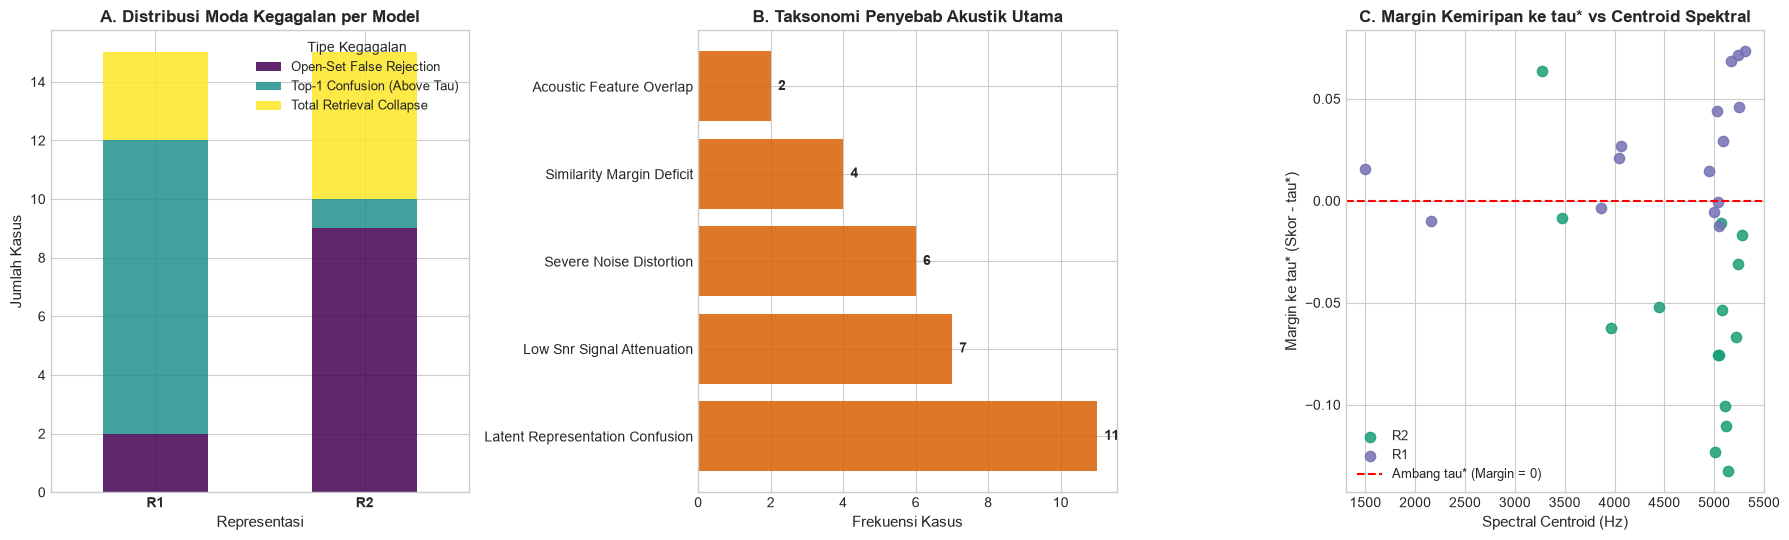

In [3]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Subplot 1: Tipe Kegagalan per Representasi
fail_rep = pd.crosstab(df_fail['representation'], df_fail['failure_type'])
fail_rep.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', alpha=0.85)
axes[0].set_title('A. Distribusi Moda Kegagalan per Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Kasus', fontsize=11)
axes[0].set_xlabel('Representasi', fontsize=11)
axes[0].legend(fontsize=9, title='Tipe Kegagalan', loc='upper right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontweight='bold')

# Subplot 2: Penyebab Akustik Primer
cause_counts = df_fail['primary_acoustic_cause'].value_counts()
cause_labels = [c.replace('_', ' ').title() for c in cause_counts.index]
axes[1].barh(cause_labels, cause_counts.values, color='#d95f02', alpha=0.85)
axes[1].set_title('B. Taksonomi Penyebab Akustik Utama', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frekuensi Kasus', fontsize=11)
for i, v in enumerate(cause_counts.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontweight='bold', fontsize=10)

# Subplot 3: Margin ke Threshold tau* (Scatter Margin vs Centroid)
colors = {'R2': '#1b9e77', 'R1': '#7570b3'}
for rep in ['R2', 'R1']:
    sub = df_fail[df_fail['representation'] == rep]
    axes[2].scatter(sub['spectral_centroid_hz'], sub['margin_to_tau'], color=colors[rep], label=rep, s=55, alpha=0.85)
axes[2].axhline(0, color='red', linestyle='--', label='Ambang tau* (Margin = 0)')
axes[2].set_title('C. Margin Kemiripan ke tau* vs Centroid Spektral', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Spectral Centroid (Hz)', fontsize=11)
axes[2].set_ylabel('Margin ke tau* (Skor - tau*)', fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e5_failure_analysis.png', dpi=300)
plt.savefig(PAPER_FIG_DIR / 'e5_failure_analysis.png', dpi=300)
plt.show()

### Pembahasan dan Temuan Kunci Audit Kegagalan E5:

1. **Divergensi Mekanisme Kegagalan R2 vs R1:**
   - **R2 (BirdNET) di Bawah Derau Ekstrem (-5 dB):** Didominasi oleh *Open-Set False Rejection* (9 dari 10 kasus). Pada kasus-kasus ini, BirdNET sebenarnya **berhasil menempatkan spesies target yang benar pada peringkat Top-1**, namun magnitudo kemiripan kosinus global tertekan oleh derau latar ke rentang 0.6399–0.7084, sehingga jatuh tepat di bawah ambang batas beku $\tau^* = 0.7128$. Ini membuktikan bahwa representasi BirdNET tetap mempertahankan resolusi pembeda biologis yang benar, tetapi menderita akibat ambang batas statis (*rigid frozen threshold*).
   - **R1 (PANNs CNN14) di Bawah Derau Ekstrem (-5 dB):** Didominasi oleh *Top-1 Confusion Above Tau* (7 dari 10 kasus). Derau antropogenik/lingkungan memicu pergeseran representasi (*noise-induced representation shift*), di mana vektor kueri tertarik ke klaster galeri spesies lain (misal `coffal1` tertukar ke `pirfly1` dengan skor 0.9353–0.9408). Karena skor ini melampaui $\tau^* = 0.9117$, sistem mengalami alarm palsu (*false identification*).

2. **Kegagalan Kondisi Bersih (Clean Audio):**
   - Pada kondisi tanpa derau, kegagalan R2 dan R1 disebabkan oleh:
     - *Temporal Fragmentation Short Call:* Kueri kicauan berdurasi sangat singkat/terputus-putus menghasilkan pooling temporal yang renggang.
     - *Acoustic Feature Overlap:* Tumpang tindih spektral pada spesies yang memiliki rentang frekuensi peluit nada tinggi serupa (> 4.5 kHz).
     - *Intra-species Vocal Variation:* Perbedaan dialek geografis antar-perekam (*author disjoint*) yang melebihi variasi antar-spesies.
